In [1]:
#!pip install segmentation-models-pytorch
#!pip install -U git+https://github.com/albumentations-team/albumentations
#!pip install --upgrade opencv-contrib-python

In [2]:
!nvidia-smi

Mon Jul  1 14:26:58 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0 Off |                  N/A |
|  0%   42C    P8              23W / 370W |      1MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Dataset

In [3]:
#!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

In [4]:
#import sys
#sys.path.append('Human-Segmentation-Dataset-master')

In [5]:
import torch 
import cv2

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

## Task : 2 Setup Configurations


In [6]:
#CSV_FILE = 'Human-Segmentation-Dataset-master/train.csv'
CSV_FILE = 'DataFN.csv'
CSV_testFILE = 'DataTestFN.csv'
CSV_testFILE0 = 'DataTestFN0.csv'
CSV_testFILE100 = 'DataTestFN100.csv'
DATA_DIR = ''

DEVICE = 'cuda'

EPOCHS = 1000
IMAGE_SIZE = 160
BATCH_SIZE = 2
Patience = 30


In [7]:
df = pd.read_csv(CSV_FILE)
test_df = pd.read_csv(CSV_testFILE)
test_df0 = pd.read_csv(CSV_testFILE0)
test_df100 = pd.read_csv(CSV_testFILE100)
df.head()

,images,masks
0,Dataset/train/Flair/P10_T1_100.png,Dataset/train/Mask/P10_T1_100.png
1,Dataset/train/Flair/P10_T1_101.png,Dataset/train/Mask/P10_T1_101.png
2,Dataset/train/Flair/P10_T1_102.png,Dataset/train/Mask/P10_T1_102.png
3,Dataset/train/Flair/P10_T1_103.png,Dataset/train/Mask/P10_T1_103.png
4,Dataset/train/Flair/P10_T1_104.png,Dataset/train/Mask/P10_T1_104.png


In [8]:
row = df.iloc[500]

image_path = row.images
mask_path = row.masks

image = cv2.imread(image_path)
#image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

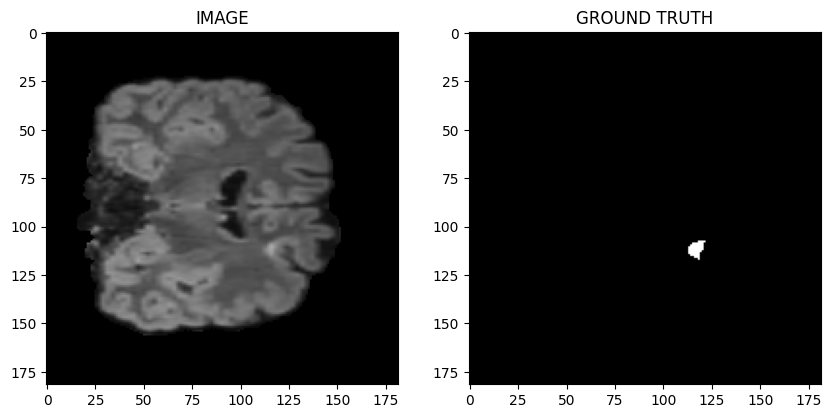

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
        
ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [10]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

## Task 3 : Augmentation Functions


In [11]:
import albumentations as A

def get_train_augs():
   return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        #A.ShiftScaleRotate(shift_limit=0.0, scale_limit=0.1, rotate_limit=0, p=0.5),
        #A.RandomBrightnessContrast(p=0.5),
        #A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
   ])
def get_valid_augs():
   return A.Compose([
   ])

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.10 (you have 1.4.8). Upgrade using: pip install --upgrade albumentations


## Task 4 : Create Custom Dataset


In [12]:
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
  def __init__(self,df, augmentations):
    self.df=df
    self.augmentations = augmentations 
  def __len__(self):
    return len(self.df)
  def __getitem__(self ,idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    #print('image path: ', image_path)
    #print('mask path: ', mask_path)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)

    mask = cv2.imread(mask_path , cv2.IMREAD_GRAYSCALE) #(h,w,c)
    #print('mask 0 size: ', mask.shape)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    mask =np.expand_dims(mask ,axis=-1)
    #print('image size: ', image.shape)
    #print('mask size: ', mask.shape)

    if self.augmentations :
      data =self.augmentations(image = image , mask = mask)
      image = data['image']
      mask = data ['mask']

    #(h,w,c) -> (c,h,w)
    image = np.transpose(image ,(2,0,1)).astype(np.float32)
    mask = np.transpose(mask ,(2,0,1)).astype(np.float32)

    image = torch.Tensor(image)/255.0
    mask = torch.round(torch.Tensor(mask)/255.0)

    return image,mask

In [13]:
trainset = SegmentationDataset(train_df,get_train_augs())
validset = SegmentationDataset(valid_df,get_valid_augs())
testset = SegmentationDataset(test_df,get_valid_augs())
testset0 = SegmentationDataset(test_df0,get_valid_augs())
testset100 = SegmentationDataset(test_df100,get_valid_augs())


In [14]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 8649
Size of Validset : 2163


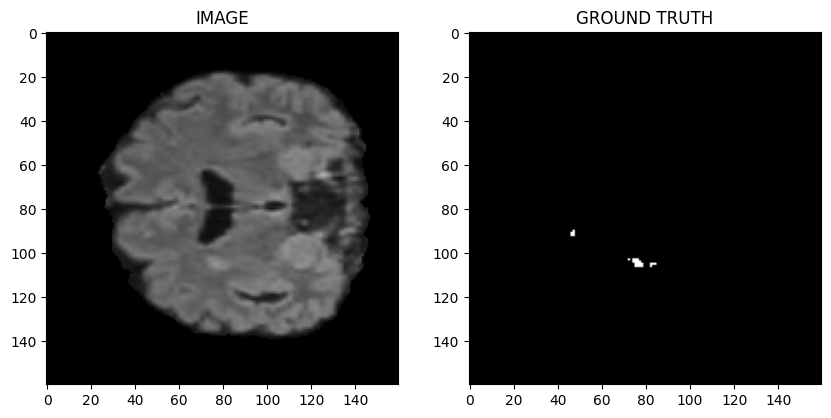

In [15]:
idx = 70
image,mask = trainset[idx]
helper.show_image(image,mask)


## Task 5 : Load dataset into batches


In [16]:
from torch.utils.data import DataLoader

trainloader = DataLoader(trainset , batch_size =BATCH_SIZE , shuffle =True )
validloader = DataLoader(validset , batch_size =BATCH_SIZE  )

In [17]:
print(f"total no,of batches in trainloader: {len(trainloader)}")
print(f"total no,of batches in validloader: {len(validloader)}")

total no,of batches in trainloader: 4325
total no,of batches in validloader: 1082


In [18]:
for image , mask in trainloader:
  break
print (f'One batch image shape: {image.shape}')
print (f'One batch image shape: {mask.shape}')

One batch image shape: torch.Size([2, 3, 160, 160])
One batch image shape: torch.Size([2, 1, 160, 160])



## Task 6 : Create Segmentation Model


In [19]:
#! pip install segmentation_models_pytorch

In [20]:
from torch import nn 
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [21]:

class BinaryIntersection(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        return  intersection

class BinaryUnion(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        #print('predict: ', pred.sum())
        #print('target : ', target.sum())
        
        return  union

A , B = 0.0011 , 0.0012
class BinaryJaccardLoss(torch.nn.Module):
    def forward(self, pred, target):
       if (pred.sum() ==0) and (target.sum() == 0):
            jaccard_index = 1
       else:        
            intersection = (pred * target).sum() + A
            union = pred.sum() + target.sum() - intersection + B
            jaccard_index = 1 - intersection / (union)
       return  jaccard_index


In [22]:
class MHSAHead(nn.Module):
  def __init__(self, in_channels, num_heads=8, d_model=None):
    super().__init__()
    if d_model is None:
      d_model = in_channels

    self.num_heads = num_heads
    self.d_model = d_model

    # Linear transformations for queries, keys, and values
    self.q_linear = nn.Linear(in_channels, d_model * num_heads)
    self.k_linear = nn.Linear(in_channels, d_model * num_heads)
    self.v_linear = nn.Linear(in_channels, d_model * num_heads)

    # Weight matrix for the final projection
    self.out_proj = nn.Linear(d_model * num_heads, d_model)

  def forward(self, x):
    # Project input features to queries, keys, and values
    q = self.q_linear(x).view(x.size(0), -1, self.num_heads, self.d_model)
    k = self.k_linear(x).view(x.size(0), -1, self.num_heads, self.d_model)
    v = self.v_linear(x).view(x.size(0), -1, self.num_heads, self.d_model)

    # Transpose for efficient attention calculation
    q = q.transpose(2, 0, 1)  # (num_heads, batch_size, seq_len, d_model)
    k = k.transpose(2, 0, 1)  # (num_heads, batch_size, seq_len, d_model)
    v = v.transpose(2, 0, 1)  # (num_heads, batch_size, seq_len, d_model)

    # Scaled Dot-Product Attention
    scores = torch.bmm(q, k.transpose(-2, -1)) / math.sqrt(self.d_model)  # (num_heads, batch_size, seq_len, seq_len)
    scores = F.softmax(scores, dim=-1)  # Apply softmax for attention weights

    # Context vector calculation
    context = torch.bmm(scores, v)  # (num_heads, batch_size, seq_len, d_model)

    # Concatenate heads and apply final projection
    context = context.transpose(2, 0, 1).contiguous().view(x.size(0), -1, self.d_model * self.num_heads)
    output = self.out_proj(context)

    return output


In [23]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)


In [24]:
class E_MHSA(nn.Module):
    """
    Efficient Multi-Head Self Attention
    """
    def __init__(self, dim, out_dim=None, head_dim=4, qkv_bias=True, qk_scale=None,
                 attn_drop=0, proj_drop=0., sr_ratio=1):
        super().__init__()
        self.dim = dim
        self.out_dim = out_dim if out_dim is not None else dim
        self.num_heads = self.dim // head_dim
        self.scale = qk_scale or head_dim ** -0.5
        self.q = nn.Linear(dim, self.dim, bias=qkv_bias)
        self.k = nn.Linear(dim, self.dim, bias=qkv_bias)
        self.v = nn.Linear(dim, self.dim, bias=qkv_bias)
        self.proj = nn.Linear(self.dim, self.out_dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

        self.sr_ratio = sr_ratio
        self.N_ratio = sr_ratio ** 2
        if sr_ratio > 1:
            self.sr = nn.AvgPool1d(kernel_size=self.N_ratio, stride=self.N_ratio)
            self.norm = nn.BatchNorm1d(dim, eps=NORM_EPS)
        self.is_bn_merged = False

    def merge_bn(self, pre_bn):
        merge_pre_bn(self.q, pre_bn)
        if self.sr_ratio > 1:
            merge_pre_bn(self.k, pre_bn, self.norm)
            merge_pre_bn(self.v, pre_bn, self.norm)
        else:
            merge_pre_bn(self.k, pre_bn)
            merge_pre_bn(self.v, pre_bn)
        self.is_bn_merged = True

    def forward(self, x):
        B, N, C = x.shape
        q = self.q(x)
        q = q.reshape(B, N, self.num_heads, int(C // self.num_heads)).permute(0, 2, 1, 3)

        if self.sr_ratio > 1:
            x_ = x.transpose(1, 2)
            x_ = self.sr(x_)
            if not torch.onnx.is_in_onnx_export() and not self.is_bn_merged:
                x_ = self.norm(x_)
            x_ = x_.transpose(1, 2)
            k = self.k(x_)
            k = k.reshape(B, -1, self.num_heads, int(C // self.num_heads)).permute(0, 2, 3, 1)
            v = self.v(x_)
            v = v.reshape(B, -1, self.num_heads, int(C // self.num_heads)).permute(0, 2, 1, 3)
        else:
            k = self.k(x)
            k = k.reshape(B, -1, self.num_heads, int(C // self.num_heads)).permute(0, 2, 3, 1)
            v = self.v(x)
            v = v.reshape(B, -1, self.num_heads, int(C // self.num_heads)).permute(0, 2, 1, 3)
        attn = (q @ k) * self.scale

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


In [25]:
from einops import rearrange

ENCODER = 'efficientnet-b1'
WEIGHTS = 'imagenet'

class SegmentationModel (nn.Module):

  def __init__(self):
    super (SegmentationModel , self).__init__()

    self.conv1 = nn.Conv2d(4, 1, kernel_size=1, padding=0)
    self.e_mhsa = E_MHSA(4)
    #self.mhsa1 = MHSAHead(64)
      
    self.arc = smp.Unet(
        encoder_name= ENCODER ,
        encoder_weights=  WEIGHTS ,
        in_channels= 3 ,
        classes=  4 ,
        activation = None
    )

  def forward (self ,images ,masks = None):
    B, C, H, W = images.shape
    #x1 = self.conv1(images)
    out = self.arc(images)
    out = rearrange(out, "b c h w -> b (h w) c")  # b n c
    out = self.e_mhsa(out)
    out = rearrange(out, "b (h w) c -> b c h w", h=H)
    out = self.conv1(out)
    result = torch.sigmoid (out)
      
    if masks != None :
      #print(f'max of result = {result.max()}  , max of mask = {masks.max()}')
      #loss1 = DiceLoss(mode='binary')(result , masks)
      #loss1 = nn.BCEWithLogitsLoss()(result , masks)
      #loss1 = nn.CrossEntropyLoss()(result , masks)
      loss1 = BinaryJaccardLoss()(result , masks)
      #print('loss: ', loss1)
      return result , loss1
    return result

In [26]:
model = SegmentationModel()
model.to(DEVICE)

SegmentationModel(
  (conv1): Conv2d(4, 1, kernel_size=(1, 1), stride=(1, 1))
  (e_mhsa): E_MHSA(
    (q): Linear(in_features=4, out_features=4, bias=True)
    (k): Linear(in_features=4, out_features=4, bias=True)
    (v): Linear(in_features=4, out_features=4, bias=True)
    (proj): Linear(in_features=4, out_features=4, bias=True)
    (attn_drop): Dropout(p=0, inplace=False)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (arc): Unet(
    (encoder): EfficientNetEncoder(
      (_conv_stem): Conv2dStaticSamePadding(
        3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
        (static_padding): ZeroPad2d((0, 1, 0, 1))
      )
      (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_blocks): ModuleList(
        (0): MBConvBlock(
          (_depthwise_conv): Conv2dStaticSamePadding(
            32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
            (static_padding): ZeroPad2d((1, 1, 1, 1))
     

In [27]:
from torchsummary import summary
summary(model, (3, 192, 192))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         ZeroPad2d-1          [-1, 3, 193, 193]               0
Conv2dStaticSamePadding-2           [-1, 32, 96, 96]             864
       BatchNorm2d-3           [-1, 32, 96, 96]              64
MemoryEfficientSwish-4           [-1, 32, 96, 96]               0
         ZeroPad2d-5           [-1, 32, 98, 98]               0
Conv2dStaticSamePadding-6           [-1, 32, 96, 96]             288
       BatchNorm2d-7           [-1, 32, 96, 96]              64
MemoryEfficientSwish-8           [-1, 32, 96, 96]               0
          Identity-9             [-1, 32, 1, 1]               0
Conv2dStaticSamePadding-10              [-1, 8, 1, 1]             264
MemoryEfficientSwish-11              [-1, 8, 1, 1]               0
         Identity-12              [-1, 8, 1, 1]               0
Conv2dStaticSamePadding-13             [-1, 32, 1, 1]             288
         I

/home/jupyter-ziaratban_stu4/.local/lib/python3.10/site-packages/torchsummary/torchsummary.py:93: RuntimeWarning: overflow encountered in scalar add
  total_output += np.prod(summary[layer]["output_shape"])



## Task 7 : Create Train and Validation Function


In [28]:
def train_fn (data_loader , model , optimizer):
  model.train()
  total_loss =0.0

  for images, masks in tqdm(data_loader) :

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits , loss = model(images ,masks)
    loss.backward()
    optimizer.step()

    total_loss +=loss.item()

    return total_loss / len(data_loader)

In [29]:
def eval_fn (data_loader , model ):

  model.eval()
  total_loss =0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader) :

      images = images.to(DEVICE)
      masks = masks.to(DEVICE)

      logits , loss = model(images ,masks)

      total_loss +=loss.item()

  return total_loss / len(data_loader)


## Task 8 : Train Model


In [30]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        #torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=Patience, verbose=True)


In [31]:
import GPUtil
from torch.optim.lr_scheduler import ReduceLROnPlateau

LR = 0.01
LR_Reduce_freq = 20

optimizer = torch.optim.Adam(model.parameters(),lr= LR)
#scheduler = ReduceLROnPlateau(optimizer, 'min')
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)


best_valid_loss = np.Inf
for i in range(EPOCHS):
    GPUtil.showUtilization()
    print('Learning rate = ', scheduler.get_last_lr()[0])
    train_loss = train_fn(trainloader , model , optimizer)
    #print('train_loss = ', train_loss)
    valid_loss = eval_fn(validloader , model  )
    #print('valid_loss = ', valid_loss)

    if valid_loss< best_valid_loss :
        torch.save(model.state_dict(), 'bestModel.pt')
        print ("SAVED")
        best_valid_loss = valid_loss
    print(f"Epoch : {i+1} train_loss :{train_loss} valid_loss :{valid_loss}" )
    
    if (i+1) % LR_Reduce_freq == 0:
        scheduler.step()
    early_stopping(valid_loss, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break
    

| ID | GPU | MEM |
------------------
|  0 | 27% | 87% |
Learning rate =  0.01


100%|██████████| 1082/1082 [01:08<00:00, 15.70it/s]


SAVED
Epoch : 1 train_loss :0.00023060765569609713 valid_loss :0.9977450016576129
Validation loss decreased (inf --> 0.997745).  Saving model ...
| ID | GPU | MEM |
------------------
|  0 | 91% | 87% |
Learning rate =  0.01


100%|██████████| 1082/1082 [01:06<00:00, 16.23it/s]


SAVED
Epoch : 2 train_loss :0.00023103310193629622 valid_loss :0.9977348521214096
Validation loss decreased (0.997745 --> 0.997735).  Saving model ...
| ID | GPU | MEM |
------------------
|  0 | 96% | 88% |
Learning rate =  0.01


...

SAVED
Epoch : 12 train_loss :0.00021494749653546108 valid_loss :0.8991215289630643
Validation loss decreased (0.968061 --> 0.899122).  Saving model ...
| ID | GPU | MEM |
------------------
|  0 | 84% | 88% |
Learning rate =  0.01


100%|██████████| 1082/1082 [01:06<00:00, 16.21it/s]


SAVED
Epoch : 13 train_loss :0.00017725001869863167 valid_loss :-0.002122641601315708
Validation loss decreased (0.899122 --> -0.002123).  Saving model ...
| ID | GPU | MEM |
------------------
|  0 | 92% | 88% |
Learning rate =  0.01


  0%|          | 2/1082 [00:00<01:40, 10.78it/s]


AttributeError: 'int' object has no attribute 'item'


## Task 9 : Inference


In [ ]:
idx = 689
model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
print(f'Jaccard = , {J} ,  Intersection = {I} , Union = {U}')


helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

In [ ]:
idx = 40
model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
print(f'Jaccard = , {J} ,  Intersection = {I} , Union = {U}')


helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

In [ ]:
J = [0]*len(validset)
I = [0]*len(validset)
U = [0]*len(validset)
for idx in range(len(validset)):
    image, mask = validset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_valid = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of validation set = ', torch.mean(J_valid)*100)


In [ ]:
J = [0]*len(testset)
I = [0]*len(testset)
U = [0]*len(testset)
sx, su = 0, 0
for idx in range(len(testset)):
    image, mask = testset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)


In [ ]:
J = [0]*len(testset0)
I = [0]*len(testset0)
U = [0]*len(testset0)
sx, su = 0, 0
for idx in range(len(testset0)):
    image, mask = testset0[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)


In [ ]:
J = [0]*len(testset100)
I = [0]*len(testset100)
U = [0]*len(testset100)
sx, su = 0, 0
for idx in range(len(testset100)):
    image, mask = testset100[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)

